# Tarea 7. Gracida Salgado Angel David

1) Carga el conjunto de datos MNIST. De los 70,000 dígitos que tienes, selecciona solo los primeros 2000 dígitos. Crea un conjunto de entrenamiento

(1,500 dígitos) y un conjunto de prueba (500 dígitos).

In [7]:
#Descargamos el conjunto de datos y seleccionamos los primeros 2000
import numpy as np
from sklearn.datasets import fetch_openml
dataset = fetch_openml("mnist_784")
X = dataset.data
y = dataset.target

X1=X[:2000]
y1=y[:2000]


In [8]:
  X1.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
y1.head()

,class
0,5
1,0
2,4
3,1
4,9


In [16]:
#Dividiamos el conjunto de datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X1,y1,test_size=0.25,random_state=123)

2) Entrena un bosque aleatorio y calcula su precisión contra el conjunto de
prueba.

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
#Entrenamos el bosque
clf = RandomForestClassifier(n_estimators=100,max_depth=5, random_state=123)
clf.fit(X_train, y_train)
CLA=classification_report(y_test, clf.predict(X_test))
print(CLA)

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        56
           1       0.79      0.97      0.87        62
           2       0.90      0.73      0.80        51
           3       0.74      0.82      0.78        38
           4       0.85      0.86      0.85        51
           5       0.93      0.72      0.81        36
           6       0.86      0.92      0.89        53
           7       0.79      0.83      0.81        54
           8       0.92      0.75      0.82        44
           9       0.80      0.80      0.80        55

    accuracy                           0.84       500
   macro avg       0.85      0.83      0.84       500
weighted avg       0.85      0.84      0.84       500



3) Calcula la importancia de las 784 características de MNIST según tu
bosque aleatorio (para calcular la importancia de cada  ́arbol, puedes usar
la importancia precomputada de sklearn, tree.feature importances .
feature_importances = get_feature_importances(clf)

In [29]:
# Entendí que hay que calcular la importancia de características para cada uno de los 100 árboles de desición del bosque aleatorio

from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd
PP = [] #importancias para cada arbol

for i in clf.estimators_:  #buscamos la importancia de caracteristicas para cada uno de los arboles y los guardamos en una lista PP
  k=i.feature_importances_
  PP.append(k)

# lo convertimos a array
PP=np.array(PP) #transformamos a array la lista original
print(len(PP[0])) #Tamaño del array de las 784 caracteristicas para el primer arbol


784


4) A partir del ejercicio anterior, ahora deberías tener un arreglo con 784
importancias de características, una para cada una de las características en
MNIST. Remodela este arreglo en una matriz de 28×28 valores (recuerda
que las imágenes de MNIST son de 28 × 28 en blanco y negro) y usa la
biblioteca seaborn para visualizar un mapa de calor de esta matriz.

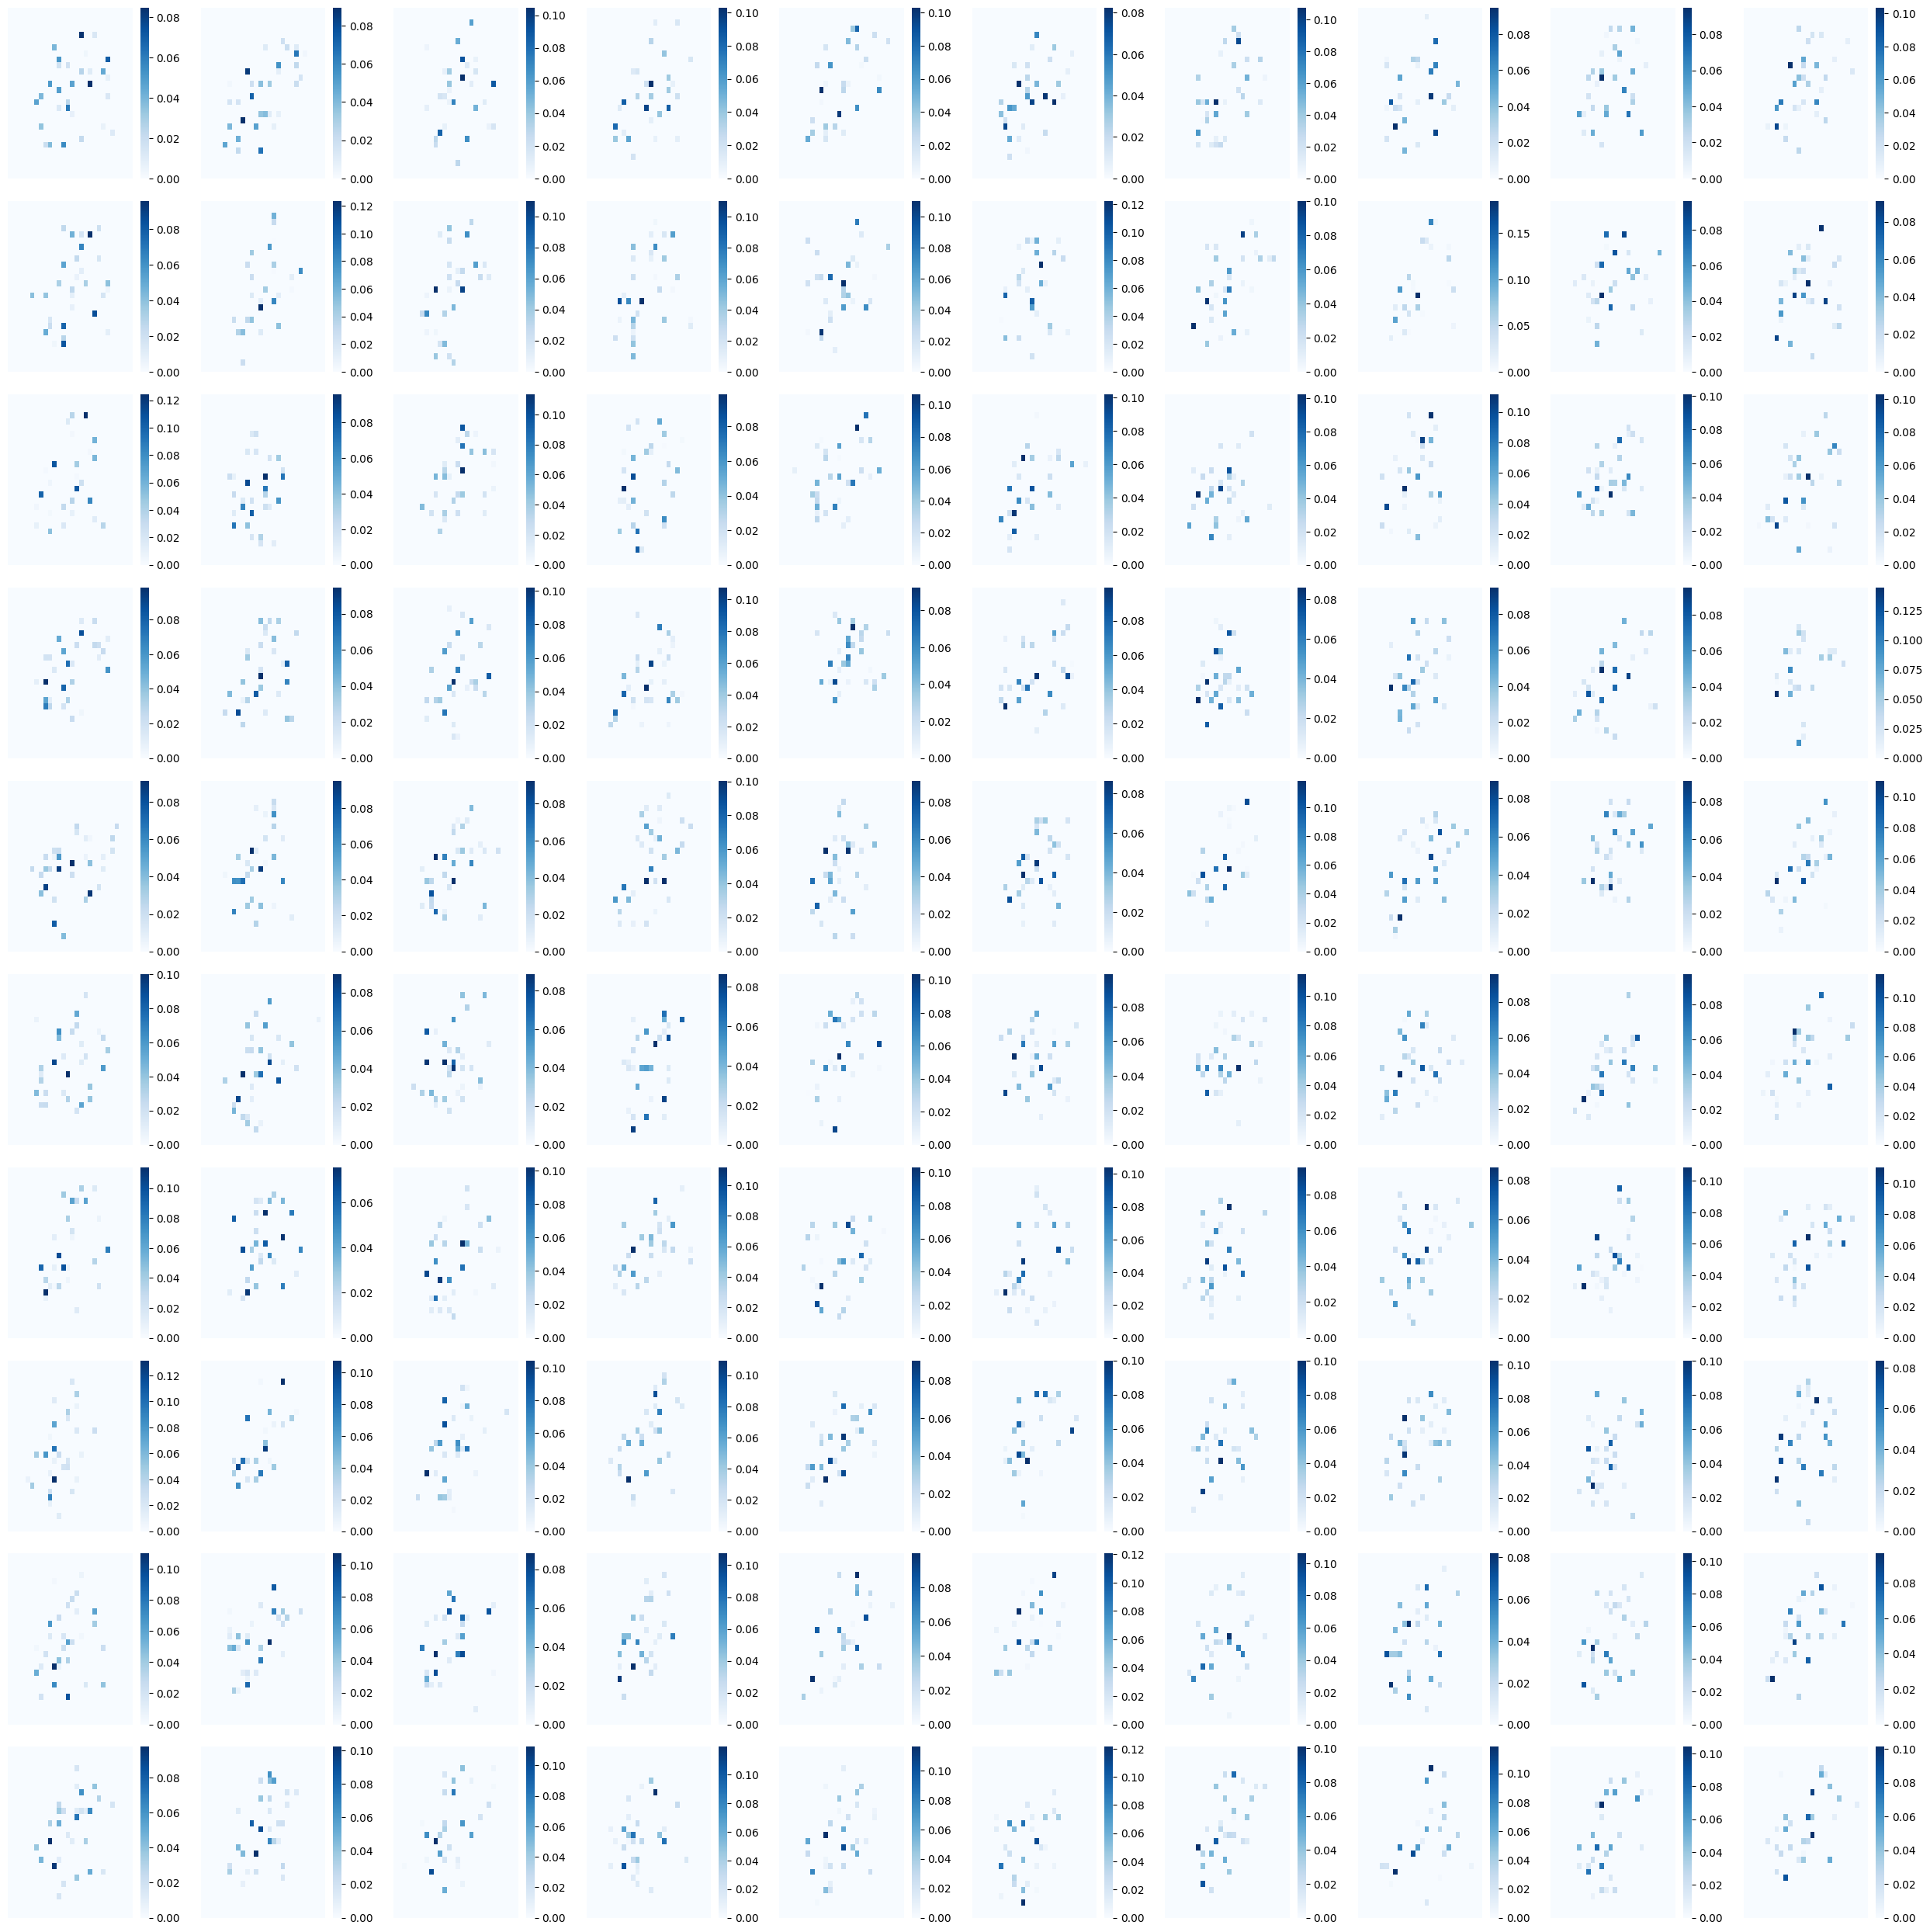

In [36]:
#Vamos a graficar en seaborn cada uno de los 100 mapas de densidad de 784 caracteristicas
HH=[]
for i in range(100):
  HH.append(PP[i].reshape(28,28)) #hacemos que todos los arreglos tengan forma de matriz de 28x28

fig,axes=plt.subplots(10, 10, figsize=(25, 25)) #tamaño de mi matriz de graficas

#aplanamos los ejes para iterar mejor y creamos las 100 graficas de densidad, cada una con 784 importancias de caracteristivas
planos = axes.flatten()
for i, ax in enumerate(planos):
    datos_planos = HH[i]
    sns.heatmap(datos_planos, cmap="Blues", ax=ax,
                xticklabels=False, yticklabels=False) #pongo en falso las etiquetas de los ejes para que le cueste menos trabajo la iteración y no se vea tan saturado
plt.tight_layout()
plt.show()

Ahora entrena un bosque aleatorio, extrae su importancia de características
(rf.feature importances ) y visualízalo. Cuáles son las características
más importantes?

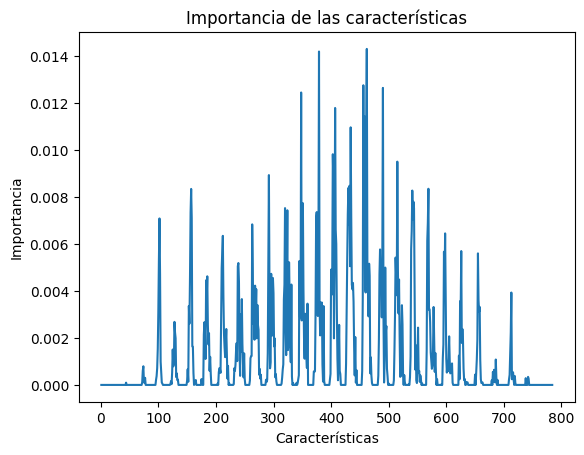

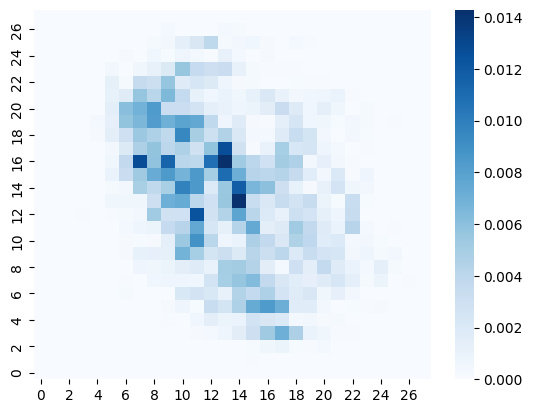

In [38]:
import seaborn as sns
#Vamos a graficar estas importancias, son valores normalizados de cero a 1, mientras mas cercanos a 1, mas importantes son para los árboles
import matplotlib.pyplot as plt
Dd=clf.feature_importances_
H=np.linspace(1,784,784)
plt.title("Importancia de las características")
plt.xlabel("Características")
plt.ylabel("Importancia")
plt.plot(H,Dd)
plt.show()
#Graficamos el mapa de calor para el bosque completo
DD=Dd.reshape(28,28)
sns.heatmap(Dd.reshape(28,28),cmap="Blues") #graficamos el mapa de calor
plt.ylim(0,28) #arreglamos ambos ejes para que empiecen en cero
plt.xlim(0,28)
plt.show()

Las características más importantes son de los pixeles 300 a 500, que serían la parte central del gráfico de calor